# **FINAL PROJECT REPORT**

## Student Details

- Full name: Đỗ Phan Tuấn Đạt
- Student ID: 22127057

## Course Details

- Course name: Statistical Machine learning
- Course ID: CSC15004

---

## Project Details

- Chosen problem: Sentiment Analysis
- Chosen model: distilbert/distilbert-base-uncased
- Chosen dataset: GoEmotions

### Problem Details

**Sentiment analysis**, also know as opinion mining, is a type of text classification that involves determining the emotional tone or attitude expressed in text. The simplest form of this problem features classifying texts into positive/neutral/negative tones. However, my project aims to train a model to identify specific emotions, so it is also reasonable to refer to this topic as **emotion analysis**.

### Model Details

- Model name: distilbert/distilbert-base-uncased
- Source & Documentations: https://huggingface.co/distilbert/distilbert-base-uncased

A distiled version of the BERT base model. This model has **67 million tensors**, which is **40% smaller** than BERT, while retaining **97%** of BERT's natural language processing performance, as well as being **60% faster**. The model's small size also reduces memory usage, which is necesary for building a locally deployed website on my laptop with only 16GB RAM and no dedicated GPU.

### Dataset Details

- Dataset name: GoEmotions
- Source & Documentations: https://www.kaggle.com/datasets/debarshichanda/goemotions/data

The expanded version of the Google-released corpus of Reddit comments, annotated to 27 emotional states, or neutral, by humans.

Number of instances: **211225 rows**

Features in each instance:
- `text`: The text of the Reddit comment.
- `id`: The unique id of the comment.
- `author`: Username of the Redditor who wrote the comment.
- `subreddit`: The subreddit containing the thread in which the comment was written.
- `link_id`: The link id of the comment.
- `parent_id`: The parent id of the comment.
- `created_utc`: The timestamp of the comment.
- `rater_id`: The unique id of the human annotator who classified the comment.
- `example_very_unclear`: Whether the annotator marked the example as being very unclear or difficult to label, leading to no classification label selected.
- Separate columns representing each of the emotion categories, with binary labels (0 or 1). Featured emotion categories are: `admiration`, `amusement`, `anger`, `annoyance`, `approval`, `caring`, `confusion`, `curiosity`, `desire`, `disappointment`, `disapproval`, `disgust`, `embarrassment`, `excitement`, `fear`, `gratitude`, `grief`, `joy`, `love`, `nervousness`, `optimism`, `pride`, `realization`, `relief`, `remorse`, `sadness`, `surprise`, and `neutral`.

Every comment can express more than one emotional state (for example, both `pride` and `joy`), so the topic now becomes a multiclass classification problem.

Data quality:
- The dataset has no missing value or duplicated instance.
- Apart from the original 58k carefully curated instances provided by Google, the rest of the dataset was labeled by an emotion pilot model, which was trained on reviewed examples.
- Quoted from documentation: "Potential biases in the data include: Inherent biases in Reddit and user base biases, the offensive/vulgar word lists used for data filtering, inherent or unconscious bias in assessment of offensive identity labels, annotators were all native English speakers from India. All these likely affect labelling, precision, and recall for a trained model."

---

## Workflow

### Data Preprocessing

### Model Training

### Model Evaluation

In [1]:
# Import necessary libraries

import pandas as pd
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data and model

test_df = pd.read_csv('data/test_data.csv')

model_dir = 'models/trained-distilbert-base-uncased'
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir)

In [3]:
# Get emotion columns
emotion_columns = [col for col in test_df.columns if col != 'text']

# Tokenize texts
inputs = tokenizer(
    test_df['text'].tolist(),
    padding=True,
    truncation=True,
    return_tensors='pt'
)

# True labels
y_true = test_df[emotion_columns].values

In [ ]:
# Perform inference

batch_size = 128 # Split the inference into batches to avoid memory issues
all_preds = []

model.eval()
with torch.no_grad():
    for i in range(0, len(test_df), batch_size):
        batch_texts = test_df['text'].iloc[i:i+batch_size].tolist()
        batch_inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            return_tensors='pt'
        )
        outputs = model(**batch_inputs)
        logits = outputs.logits
        preds = (torch.sigmoid(logits).cpu().numpy() > 0.65).astype(int) # Thresholding at 0.65
        all_preds.append(preds)

y_pred = np.vstack(all_preds)

In [5]:
# CLassification report
report = classification_report(y_true, y_pred, target_names=emotion_columns)
print(report)

                precision    recall  f1-score   support

    admiration       0.70      0.41      0.52      1677
     amusement       0.68      0.22      0.33       875
         anger       0.63      0.07      0.13       835
     annoyance       0.71      0.00      0.01      1424
      approval       0.69      0.04      0.08      1729
        caring       0.76      0.04      0.07       606
     confusion       0.71      0.06      0.11       709
     curiosity       0.64      0.07      0.13       953
        desire       0.74      0.05      0.10       383
disappointment       1.00      0.01      0.03       836
   disapproval       0.50      0.00      0.00      1176
       disgust       0.81      0.08      0.15       571
 embarrassment       0.63      0.09      0.16       259
    excitement       0.82      0.06      0.12       513
          fear       0.74      0.25      0.38       353
     gratitude       0.90      0.75      0.82      1135
         grief       0.00      0.00      0.00  

c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\Desktop\Workspace\StatisticalLearning\finals\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


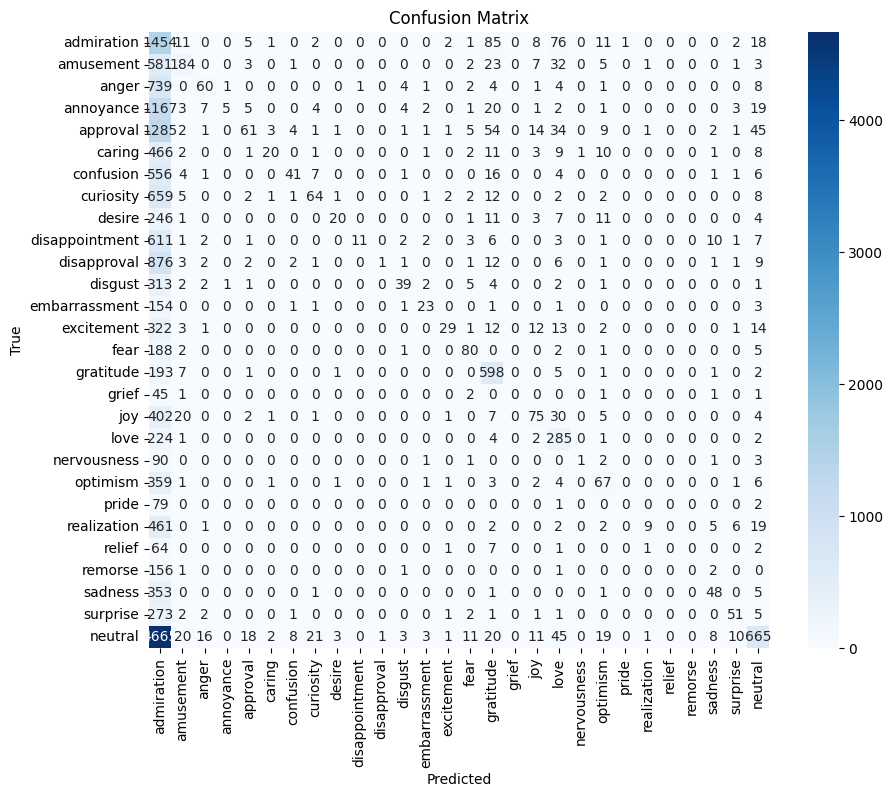

In [6]:
# Confusion matrix
cm = confusion_matrix(y_true.argmax(axis=1), y_pred.argmax(axis=1))
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotion_columns, yticklabels=emotion_columns)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


---

## Reference Materials

- https://arxiv.org/abs/1910.01108
- https://huggingface.co/datasets/google-research-datasets/go_emotions